# QPA Fidelity Decay — Unrolled Strategy — IBM Pittsburgh

This notebook runs the full QPA experiment pipeline using **unrolled (static) circuits** on `ibm_pittsburgh`.

1. **Configuration** — Define experiment parameters
2. **Backend Setup** — Connect to IBM Quantum hardware (`ibm_pittsburgh`)
3. **Circuit Generation** — Build unrolled circuits for all execution paths
4. **Transpilation** — Compile circuits for the target hardware
5. **Noise Application** — Apply Pauli Twirling noise for each λ point
6. **Submission** — Send circuits to IBM and collect results
7. **Result Processing** — Extract counts, filter by path conditions, compute fidelity
8. **Plotting** — Compare experimental fidelity decay against theory

**Experiments:**
- N=3, K=2, T=1 (3 registers, 2 qubits each, 1 trial round)
- N=5, K=2, T=1 (5 registers, 2 qubits each, 1 trial round)

**Sampling budget:** N_RANDOM × N_PUBS = 4000 × 4 = 16000 total samples per λ point.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from collections import defaultdict
from tqdm.notebook import tqdm

from core.circuit_factory import CircuitFactory
from core.noise_models import PauliTwirlingStrategy
from execution.backend_handler import IBMRuntimeHandler
from execution.transpiler_service import TranspilerService
from analysis.result_processor import ResultProcessor
from analysis.fidelity_calc import calculate_success_rate

from qiskit.circuit import CircuitInstruction
from qiskit.circuit.library import XGate, RZGate
from qiskit_ibm_runtime import SamplerV2 as IBMSampler

print("Imports loaded.")

Imports loaded.


## Step 1: Configuration

| Parameter | Description | Value |
|-----------|-------------|-------|
| `N` | Number of registers (must be odd) | 3, 5 |
| `K` | Qubits per register (qudit dimension d=2^k) | 2 |
| `T` (n_trials) | Number of QPA trial rounds | 1 |
| `POINTS` | Number of λ (noise) values to sweep | 25 |
| `LAMBDA_MIN/MAX` | Noise parameter range | 0.0 – 1.0 |
| `N_RANDOM` | Pauli twirling instances per λ point | 4000 |
| `SHOTS` | Shots (pubs) per circuit instance | 4 |
| `BATCH_SIZE` | Circuits per IBM job submission | 50 |
| `DEVICE` | IBM Quantum backend | ibm_pittsburgh |

In [2]:
# ----- Experiment Parameters -----
K = 2                # Qubits per register (d = 2^K = 4)
T = 1                # Number of QPA trial rounds
POINTS = 25          # Number of lambda values in the sweep
LAMBDA_MIN = 0.0     # Minimum noise parameter
LAMBDA_MAX = 1.0     # Maximum noise parameter
N_RANDOM = 100      # Pauli twirling instances per circuit (ensemble size)
SHOTS = 10000            # Shots (pubs) per circuit instance
BATCH_SIZE = 50      # Max circuits per job submission
DEVICE = "ibm_pittsburgh"  # IBM Quantum backend
NO_RESET = False     # Reuse ancillas with reset (standard mode)

# The two experiments
EXPERIMENTS = [
    {"n": 3, "k": K, "t": T, "label": "N=3, K=2, T=1"},
    {"n": 5, "k": K, "t": T, "label": "N=5, K=2, T=1"},
]

# Derived
lambdas = np.linspace(LAMBDA_MIN, LAMBDA_MAX, POINTS)

print(f"Lambda sweep: {POINTS} points from {LAMBDA_MIN} to {LAMBDA_MAX}")
print(f"Shots per circuit instance: {SHOTS}")
print(f"Pauli twirling instances per lambda: {N_RANDOM}")
print(f"Total samples per lambda: {N_RANDOM * SHOTS}")
print(f"Experiments: {[e['label'] for e in EXPERIMENTS]}")

Lambda sweep: 25 points from 0.0 to 1.0
Shots per circuit instance: 10000
Pauli twirling instances per lambda: 100
Total samples per lambda: 1000000
Experiments: ['N=3, K=2, T=1', 'N=5, K=2, T=1']


## Step 2: Backend Setup

Connect to `ibm_pittsburgh` via `QiskitRuntimeService`.

In [3]:
# Initialize the IBM Runtime backend handler
backend_handler = IBMRuntimeHandler(backend_name=DEVICE)
backend = backend_handler.get_backend()

print(f"Backend: {backend.name}")
print(f"Number of qubits: {backend.num_qubits}")
print(f"Backend status: {backend.status()}")

qiskit_runtime_service._discover_account:WARNING:2026-04-16 17:38:32,832: Loading account with the given token. A saved account will not be used.


Connecting to IBM Runtime Service via channel='ibm_cloud'...
Backend: ibm_pittsburgh
Number of qubits: 156
Backend status: <qiskit_ibm_runtime.models.backend_status.BackendStatus object at 0x1170134d0>


## Step 3: Circuit Generation (Unrolled Strategy)

The **unrolled** strategy pre-computes all possible execution paths as separate static circuits.

- For N=3 (1 pair per trial): 2 paths
- For N=5 (2 pairs per trial): 4 paths

We build **golden circuits** (no noise) to inspect and transpile.

In [4]:
# Build golden (noiseless) circuits for each experiment
golden_data_per_exp = {}

for exp in EXPERIMENTS:
    n = exp["n"]
    label = exp["label"]
    
    # Create the unrolled strategy (no noise yet)
    strategy = CircuitFactory.create_strategy("unrolled", K, T, n, no_reset=NO_RESET)
    strategy.set_noise_strategy(None)
    
    # Build circuits with epsilon=0 (no noise)
    golden_data = strategy.build(0.0)
    
    golden_circuits = [item['circuit'] for item in golden_data]
    golden_metadata = [{k: v for k, v in item.items() if k != 'circuit'} for item in golden_data]
    
    golden_data_per_exp[n] = {
        'circuits': golden_circuits,
        'metadata': golden_metadata,
        'strategy': strategy
    }
    
    print(f"\n--- {label} ---")
    print(f"  Total unrolled paths (circuits): {len(golden_circuits)}")
    print(f"  Qubits per circuit: {golden_circuits[0].num_qubits}")
    print(f"  Classical bits per circuit: {golden_circuits[0].num_clbits}")
    
    for i, meta in enumerate(golden_metadata[:4]):
        conds = meta.get('conditions', {})
        path_name = meta.get('metadata', {}).get('path_name', f'path_{i}')
        print(f"  {path_name}: conditions = {conds}")


--- N=3, K=2, T=1 ---
  Total unrolled paths (circuits): 2
  Qubits per circuit: 7
  Classical bits per circuit: 3
  path_0: conditions = {2: 0}
  path_1: conditions = {2: 1}

--- N=5, K=2, T=1 ---
  Total unrolled paths (circuits): 4
  Qubits per circuit: 12
  Classical bits per circuit: 4
  path_0: conditions = {2: 0, 3: 0}
  path_1: conditions = {2: 0, 3: 1}
  path_2: conditions = {2: 1, 3: 0}
  path_3: conditions = {2: 1, 3: 1}


### Visualize a sample circuit

Circuit: {'conditions': {2: 0}, 'metadata': {'type': 'unrolled', 'path_name': 'path_0'}}


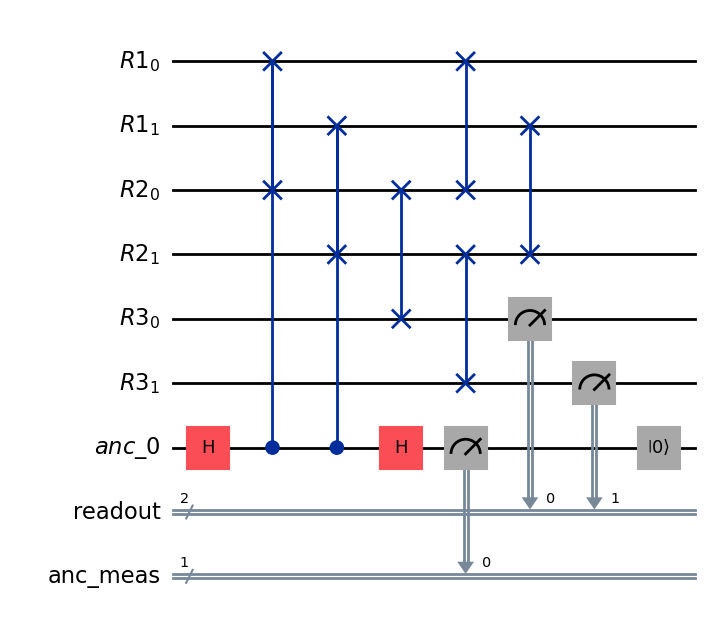

In [5]:
# Draw the first golden circuit for N=3 (all-success path)
sample_qc = golden_data_per_exp[3]['circuits'][0]
print(f"Circuit: {golden_data_per_exp[3]['metadata'][0]}")
sample_qc.draw('mpl', fold=120)

## Step 4: Transpilation

Transpile golden circuits once for `ibm_pittsburgh` at optimization level 3. These are reused for every noise instance.

In [6]:
# Transpile golden circuits for the real backend
transpiler = TranspilerService(backend, optimization_level=3)

transpiled_per_exp = {}

for exp in EXPERIMENTS:
    n = exp["n"]
    label = exp["label"]
    golden_circuits = golden_data_per_exp[n]['circuits']
    golden_metadata = golden_data_per_exp[n]['metadata']

    print(f"Transpiling {len(golden_circuits)} golden circuits for {label}...")
    transpiled = transpiler.transpile(golden_circuits)
    if not isinstance(transpiled, list):
        transpiled = [transpiled]

    transpiled_per_exp[n] = transpiled

    for i, qc in enumerate(transpiled):
        ops = dict(qc.count_ops())
        depth_2q = qc.depth(lambda instr: len(instr.qubits) == 2)
        count_2q = sum(1 for instr in qc.data if len(instr.qubits) == 2)
        path_name = golden_metadata[i].get('metadata', {}).get('path_name', f'path_{i}')
        print(f"  {path_name}: depth={qc.depth()}, 2Q depth={depth_2q}, "
              f"2Q gate count={count_2q}, gates={ops}")

print("\nAll golden circuits transpiled.")

Transpiling 2 golden circuits for N=3, K=2, T=1...
  path_0: depth=62, 2Q depth=18, 2Q gate count=20, gates={'sx': 36, 'rz': 27, 'cz': 20, 'measure': 3, 'x': 2, 'reset': 1}
  path_1: depth=62, 2Q depth=18, 2Q gate count=20, gates={'sx': 36, 'rz': 27, 'cz': 20, 'measure': 3, 'x': 2, 'reset': 1}
Transpiling 4 golden circuits for N=5, K=2, T=1...
  path_0: depth=62, 2Q depth=18, 2Q gate count=40, gates={'sx': 72, 'rz': 54, 'cz': 40, 'measure': 4, 'x': 2, 'reset': 2}
  path_1: depth=62, 2Q depth=18, 2Q gate count=40, gates={'sx': 72, 'rz': 54, 'cz': 40, 'measure': 4, 'x': 2, 'reset': 2}
  path_2: depth=62, 2Q depth=18, 2Q gate count=40, gates={'sx': 72, 'rz': 54, 'cz': 40, 'measure': 4, 'x': 2, 'reset': 2}
  path_3: depth=62, 2Q depth=18, 2Q gate count=40, gates={'sx': 72, 'rz': 54, 'cz': 40, 'measure': 4, 'x': 2, 'reset': 2}

All golden circuits transpiled.


### Draw and save circuits

Save a rendering of each golden (pre-transpilation) and transpiled circuit to `circuits_experiments/`, named by experiment and path number.

In [7]:
circuits_dir = "circuits_experiments"
os.makedirs(circuits_dir, exist_ok=True)

for exp in EXPERIMENTS:
    n = exp["n"]
    label = exp["label"]
    golden = golden_data_per_exp[n]['circuits']
    transpiled = transpiled_per_exp[n]
    metadata = golden_data_per_exp[n]['metadata']

    for i, (qc_golden, qc_transpiled) in enumerate(zip(golden, transpiled)):
        path_name = metadata[i].get('metadata', {}).get('path_name', f'path_{i}')

        fig_g = qc_golden.draw('mpl', fold=120)
        out_g = os.path.join(
            circuits_dir,
            f"golden_n{n}_k{K}_t{T}_{path_name}.png"
        )
        fig_g.savefig(out_g, dpi=200, bbox_inches='tight')
        plt.close(fig_g)
        print(f"Saved: {out_g}")

        fig_t = qc_transpiled.draw('mpl', fold=120, idle_wires=False)
        out_t = os.path.join(
            circuits_dir,
            f"transpiled_n{n}_k{K}_t{T}_ibm_pittsburgh_{path_name}.png"
        )
        fig_t.savefig(out_t, dpi=200, bbox_inches='tight')
        plt.close(fig_t)
        print(f"Saved: {out_t}")

Saved: circuits_experiments/golden_n3_k2_t1_path_0.png
Saved: circuits_experiments/transpiled_n3_k2_t1_ibm_pittsburgh_path_0.png
Saved: circuits_experiments/golden_n3_k2_t1_path_1.png
Saved: circuits_experiments/transpiled_n3_k2_t1_ibm_pittsburgh_path_1.png
Saved: circuits_experiments/golden_n5_k2_t1_path_0.png
Saved: circuits_experiments/transpiled_n5_k2_t1_ibm_pittsburgh_path_0.png
Saved: circuits_experiments/golden_n5_k2_t1_path_1.png
Saved: circuits_experiments/transpiled_n5_k2_t1_ibm_pittsburgh_path_1.png
Saved: circuits_experiments/golden_n5_k2_t1_path_2.png
Saved: circuits_experiments/transpiled_n5_k2_t1_ibm_pittsburgh_path_2.png
Saved: circuits_experiments/golden_n5_k2_t1_path_3.png
Saved: circuits_experiments/transpiled_n5_k2_t1_ibm_pittsburgh_path_3.png


## Step 5: Noise Application & Circuit Instance Generation

For each λ value and each Pauli twirling instance, we:
1. Copy the transpiled golden circuit
2. Generate random Pauli noise operations
3. Insert them at the beginning of the circuit (fast path)

Pauli gates (Z, Y) are converted to ISA-safe gates (RZ, X+RZ) for IBM hardware.

In [8]:
def build_noisy_batch(transpiled_golden, golden_circuits, golden_metadata, epsilon, n_random, batch_size):
    """
    Build batches of noisy circuit instances from pre-transpiled golden circuits.
    """
    all_batches = []
    batch_circuits = []
    batch_metadata = []
    
    for _ in range(n_random):
        noise_strategy = PauliTwirlingStrategy(K)
        
        for i, qc_transpiled in enumerate(transpiled_golden):
            qc_instance = qc_transpiled.copy()
            orig_qc = golden_circuits[i]
            
            data_regs = [reg for reg in orig_qc.qregs if reg.name.startswith("R")]
            noise_ops = noise_strategy.generate_noise_ops(data_regs, epsilon)
            
            layout = qc_transpiled.layout.initial_layout if qc_transpiled.layout else None
            
            for gate, logical_qubit in noise_ops:
                target_qubit = None
                if layout and logical_qubit in layout:
                    phys_qubit_idx = layout[logical_qubit]
                    target_qubit = qc_instance.qubits[phys_qubit_idx]
                elif logical_qubit in qc_instance.qubits:
                    target_qubit = logical_qubit
                else:
                    for q in qc_instance.qubits:
                        if hasattr(q, 'register') and hasattr(logical_qubit, 'register'):
                            if q.register.name == logical_qubit.register.name and q.index == logical_qubit.index:
                                target_qubit = q
                                break
                
                if target_qubit:
                    if gate.name == 'z':
                        qc_instance.data.insert(0, CircuitInstruction(RZGate(np.pi), (target_qubit,), ()))
                    elif gate.name == 'y':
                        qc_instance.data.insert(0, CircuitInstruction(RZGate(np.pi), (target_qubit,), ()))
                        qc_instance.data.insert(0, CircuitInstruction(XGate(), (target_qubit,), ()))
                    else:
                        qc_instance.data.insert(0, CircuitInstruction(gate, (target_qubit,), ()))
            
            batch_circuits.append(qc_instance)
            batch_metadata.append(golden_metadata[i])
            
            if len(batch_circuits) >= batch_size:
                all_batches.append((batch_circuits, batch_metadata))
                batch_circuits = []
                batch_metadata = []
    
    if batch_circuits:
        all_batches.append((batch_circuits, batch_metadata))
    
    return all_batches

# Quick test
test_batches = build_noisy_batch(
    transpiled_per_exp[3], 
    golden_data_per_exp[3]['circuits'],
    golden_data_per_exp[3]['metadata'],
    epsilon=0.5, n_random=2, batch_size=50
)
total_circuits = sum(len(b[0]) for b in test_batches)
print(f"Test: epsilon=0.5, N=3, 2 instances -> {total_circuits} circuits in {len(test_batches)} batch(es)")

Test: epsilon=0.5, N=3, 2 instances -> 4 circuits in 1 batch(es)


## Step 6: Submission to IBM Quantum

For each experiment (N=3 and N=5), sweep over all λ values. At each λ:
1. Generate `N_RANDOM` noisy circuit instances (fast path)
2. Submit them in batches to `ibm_pittsburgh`
3. Wait for results and store raw counts

In [9]:
def run_experiment(n, transpiled_golden, golden_circuits, golden_metadata, 
                   lambdas, n_random, shots_per_circuit, batch_size, backend):
    """
    Run the full lambda sweep for one experiment (one value of N).
    """
    result_processor = ResultProcessor(K)
    results = []
    
    sampler = IBMSampler(mode=backend)
    
    for epsilon in tqdm(lambdas, desc=f"N={n} lambda sweep"):
        batches = build_noisy_batch(
            transpiled_golden, golden_circuits, golden_metadata,
            epsilon, n_random, batch_size
        )
        
        global_path_stats = defaultdict(lambda: {'success': 0, 'total': 0})
        
        for batch_idx, (batch_circs, batch_meta) in enumerate(batches):
            pubs = [(qc, None, shots_per_circuit) for qc in batch_circs]
            
            try:
                job = sampler.run(pubs)
                pub_result = job.result()
                
                extracted_counts = ResultProcessor.extract_counts_from_job_result(pub_result, is_dynamic=False)
                
                total_clbits_list = []
                for counts in extracted_counts:
                    if counts:
                        first_key = next(iter(counts))
                        total_clbits_list.append(len(first_key.replace(" ", "")))
                    else:
                        total_clbits_list.append(0)
                
                batch_stats = result_processor.aggregate_batch_stats(
                    extracted_counts, batch_meta, total_clbits_list
                )
                for cond_key, stats in batch_stats.items():
                    global_path_stats[cond_key]['success'] += stats['success']
                    global_path_stats[cond_key]['total'] += stats['total']
                    
            except Exception as e:
                print(f"  Error at lambda={epsilon:.4f}, batch {batch_idx}: {e}")
                import traceback
                traceback.print_exc()
        
        fidelity = 0.0
        for stats in global_path_stats.values():
            if stats['total'] > 0:
                fidelity += stats['success'] / stats['total']
        
        results.append({'lambda': epsilon, 'fidelity': fidelity})
        print(f"  N={n}, lambda={epsilon:.4f} -> fidelity={fidelity:.4f}")
    
    return results

print("run_experiment() defined.")

run_experiment() defined.


### Run Experiment: N=3, K=2, T=1

In [10]:
results_n3 = run_experiment(
    n=3,
    transpiled_golden=transpiled_per_exp[3],
    golden_circuits=golden_data_per_exp[3]['circuits'],
    golden_metadata=golden_data_per_exp[3]['metadata'],
    lambdas=lambdas,
    n_random=N_RANDOM,
    shots_per_circuit=SHOTS,
    batch_size=BATCH_SIZE,
    backend=backend
)

df_n3 = pd.DataFrame(results_n3)
print(f"\nN=3 results: {len(df_n3)} lambda points collected")
df_n3.head()

N=3 lambda sweep:   0%|          | 0/25 [00:00<?, ?it/s]

  N=3, lambda=0.0000 -> fidelity=1.0669
  N=3, lambda=0.0417 -> fidelity=1.0265
  N=3, lambda=0.0833 -> fidelity=1.0210
  N=3, lambda=0.1250 -> fidelity=1.0409
  N=3, lambda=0.1667 -> fidelity=0.9238
  N=3, lambda=0.2083 -> fidelity=0.9262
  N=3, lambda=0.2500 -> fidelity=0.8638
  N=3, lambda=0.2917 -> fidelity=0.8793
  N=3, lambda=0.3333 -> fidelity=0.8273
  N=3, lambda=0.3750 -> fidelity=0.7705
  N=3, lambda=0.4167 -> fidelity=0.7559
  N=3, lambda=0.4583 -> fidelity=0.7567
  N=3, lambda=0.5000 -> fidelity=0.6952
  N=3, lambda=0.5417 -> fidelity=0.6011
  N=3, lambda=0.5833 -> fidelity=0.5790
  Error at lambda=0.6250, batch 0: '401 Client Error: Unauthorized for url: https://quantum.cloud.ibm.com/api/v1/jobs/d7gusf3jne2c7393e5bg?exclude_params=true. {"errors":[{"code":1219,"message":"Error authenticating user.","solution":"Your IBM Quantum API token might be incorrect, expired, or revoked.\\nLog in to IBM Quantum Platform website and navigate to your account settings to generate a new 

Traceback (most recent call last):
  File "/Users/henryzou/.venvs/opqa/lib/python3.13/site-packages/qiskit_ibm_runtime/api/session.py", line 327, in request
    response.raise_for_status()
    ~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/Users/henryzou/.venvs/opqa/lib/python3.13/site-packages/requests/models.py", line 1026, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 401 Client Error: Unauthorized for url: https://quantum.cloud.ibm.com/api/v1/jobs/d7gusf3jne2c7393e5bg?exclude_params=true

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/var/folders/jt/44gl1rhd26v6ykt0frqzl87r0000gn/T/ipykernel_46157/1032931283.py", line 24, in run_experiment
    pub_result = job.result()
  File "/Users/henryzou/.venvs/opqa/lib/python3.13/site-packages/qiskit_ibm_runtime/runtime_job_v2.py", line 126, in result
    self.wait_for_final_state(timeout=timeout)
    ~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^

  Error at lambda=0.6250, batch 1: '401 Client Error: Unauthorized for url: https://quantum.cloud.ibm.com/api/v1/jobs/d7iuqsv16ugs73eu6kug?exclude_params=true. {"errors":[{"code":1219,"message":"Error authenticating user.","solution":"Your IBM Quantum API token might be incorrect, expired, or revoked.\\nLog in to IBM Quantum Platform website and navigate to your account settings to generate a new API token.\\nUse IBMProvider.save_account(`APIKEY`, overwrite=True) to save the new API key, overwriting any outdated or incorrect credentials.","more_info":"https://cloud.ibm.com/apidocs/quantum-computing#error-handling"}],"trace":"ac2880d9-4730-421f-ab47-a3c169ecace0"}'


Traceback (most recent call last):
  File "/Users/henryzou/.venvs/opqa/lib/python3.13/site-packages/qiskit_ibm_runtime/api/session.py", line 327, in request
    response.raise_for_status()
    ~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/Users/henryzou/.venvs/opqa/lib/python3.13/site-packages/requests/models.py", line 1026, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 401 Client Error: Unauthorized for url: https://quantum.cloud.ibm.com/api/v1/jobs/d7iuqsv16ugs73eu6kug?exclude_params=true

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/var/folders/jt/44gl1rhd26v6ykt0frqzl87r0000gn/T/ipykernel_46157/1032931283.py", line 24, in run_experiment
    pub_result = job.result()
  File "/Users/henryzou/.venvs/opqa/lib/python3.13/site-packages/qiskit_ibm_runtime/runtime_job_v2.py", line 126, in result
    self.wait_for_final_state(timeout=timeout)
    ~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^

  Error at lambda=0.6250, batch 2: '401 Client Error: Unauthorized for url: https://quantum.cloud.ibm.com/api/v1/jobs/d7j06ips7cos73eja4k0?exclude_params=true. {"errors":[{"code":1219,"message":"Error authenticating user.","solution":"Your IBM Quantum API token might be incorrect, expired, or revoked.\\nLog in to IBM Quantum Platform website and navigate to your account settings to generate a new API token.\\nUse IBMProvider.save_account(`APIKEY`, overwrite=True) to save the new API key, overwriting any outdated or incorrect credentials.","more_info":"https://cloud.ibm.com/apidocs/quantum-computing#error-handling"}],"trace":"97938319-0377-4585-ba8e-ce4e68295b66"}'


Traceback (most recent call last):
  File "/Users/henryzou/.venvs/opqa/lib/python3.13/site-packages/qiskit_ibm_runtime/api/session.py", line 327, in request
    response.raise_for_status()
    ~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/Users/henryzou/.venvs/opqa/lib/python3.13/site-packages/requests/models.py", line 1026, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 401 Client Error: Unauthorized for url: https://quantum.cloud.ibm.com/api/v1/jobs/d7j06ips7cos73eja4k0?exclude_params=true

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/var/folders/jt/44gl1rhd26v6ykt0frqzl87r0000gn/T/ipykernel_46157/1032931283.py", line 24, in run_experiment
    pub_result = job.result()
  File "/Users/henryzou/.venvs/opqa/lib/python3.13/site-packages/qiskit_ibm_runtime/runtime_job_v2.py", line 126, in result
    self.wait_for_final_state(timeout=timeout)
    ~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^

KeyboardInterrupt: 

### Run Experiment: N=5, K=2, T=1

In [ ]:
results_n5 = run_experiment(
    n=5,
    transpiled_golden=transpiled_per_exp[5],
    golden_circuits=golden_data_per_exp[5]['circuits'],
    golden_metadata=golden_data_per_exp[5]['metadata'],
    lambdas=lambdas,
    n_random=N_RANDOM,
    shots_per_circuit=SHOTS,
    batch_size=BATCH_SIZE,
    backend=backend
)

df_n5 = pd.DataFrame(results_n5)
print(f"\nN=5 results: {len(df_n5)} lambda points collected")
df_n5.head()

N=5 lambda sweep:   0%|          | 0/25 [00:00<?, ?it/s]

  N=5, lambda=0.0000 -> fidelity=0.9718
  N=5, lambda=0.0417 -> fidelity=0.9569
  N=5, lambda=0.0833 -> fidelity=0.9279
  Error at lambda=0.1250, batch 258: '401 Client Error: Unauthorized for url: https://quantum.cloud.ibm.com/api/v1/jobs/d6qg49ku243c73a094s0?exclude_params=true. {"errors":[{"code":1219,"message":"Error authenticating user.","solution":"Your IBM Quantum API token might be incorrect, expired, or revoked.\\nLog in to IBM Quantum Platform website and navigate to your account settings to generate a new API token.\\nUse IBMProvider.save_account(`APIKEY`, overwrite=True) to save the new API key, overwriting any outdated or incorrect credentials.","more_info":"https://cloud.ibm.com/apidocs/quantum-computing#error-handling"}],"trace":"c06869fe-eecd-4220-b7b1-b3afa1871f8e"}'


Traceback (most recent call last):
  File "/Users/henryzou/.venvs/opqa/lib/python3.13/site-packages/qiskit_ibm_runtime/api/session.py", line 327, in request
    response.raise_for_status()
    ~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/Users/henryzou/.venvs/opqa/lib/python3.13/site-packages/requests/models.py", line 1026, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 401 Client Error: Unauthorized for url: https://quantum.cloud.ibm.com/api/v1/jobs/d6qg49ku243c73a094s0?exclude_params=true

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/var/folders/jt/44gl1rhd26v6ykt0frqzl87r0000gn/T/ipykernel_37595/1032931283.py", line 24, in run_experiment
    pub_result = job.result()
  File "/Users/henryzou/.venvs/opqa/lib/python3.13/site-packages/qiskit_ibm_runtime/runtime_job_v2.py", line 126, in result
    self.wait_for_final_state(timeout=timeout)
    ~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^

  N=5, lambda=0.1250 -> fidelity=0.9269
  Error at lambda=0.1667, batch 0: '401 Client Error: Unauthorized for url: https://quantum.cloud.ibm.com/api/v1/jobs/d6qi82i0q0ls73csc7u0?exclude_params=true. {"errors":[{"code":1219,"message":"Error authenticating user.","solution":"Your IBM Quantum API token might be incorrect, expired, or revoked.\\nLog in to IBM Quantum Platform website and navigate to your account settings to generate a new API token.\\nUse IBMProvider.save_account(`APIKEY`, overwrite=True) to save the new API key, overwriting any outdated or incorrect credentials.","more_info":"https://cloud.ibm.com/apidocs/quantum-computing#error-handling"}],"trace":"07974b22-bed7-440b-8481-112fbd2beed6"}'


Traceback (most recent call last):
  File "/Users/henryzou/.venvs/opqa/lib/python3.13/site-packages/qiskit_ibm_runtime/api/session.py", line 327, in request
    response.raise_for_status()
    ~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/Users/henryzou/.venvs/opqa/lib/python3.13/site-packages/requests/models.py", line 1026, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 401 Client Error: Unauthorized for url: https://quantum.cloud.ibm.com/api/v1/jobs/d6qi82i0q0ls73csc7u0?exclude_params=true

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/var/folders/jt/44gl1rhd26v6ykt0frqzl87r0000gn/T/ipykernel_37595/1032931283.py", line 24, in run_experiment
    pub_result = job.result()
  File "/Users/henryzou/.venvs/opqa/lib/python3.13/site-packages/qiskit_ibm_runtime/runtime_job_v2.py", line 126, in result
    self.wait_for_final_state(timeout=timeout)
    ~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^

  N=5, lambda=0.1667 -> fidelity=0.8956
  N=5, lambda=0.2083 -> fidelity=0.8824
  Error at lambda=0.2500, batch 107: 'Unable to retrieve job result. Error code 8056; Failed to execute program: A control instrument error occurred. -- https://ibm.biz/error_codes#8056'


Traceback (most recent call last):
  File "/var/folders/jt/44gl1rhd26v6ykt0frqzl87r0000gn/T/ipykernel_37595/1032931283.py", line 24, in run_experiment
    pub_result = job.result()
  File "/Users/henryzou/.venvs/opqa/lib/python3.13/site-packages/qiskit_ibm_runtime/runtime_job_v2.py", line 131, in result
    raise RuntimeJobFailureError(f"Unable to retrieve job result. {error_message}")
qiskit_ibm_runtime.exceptions.RuntimeJobFailureError: 'Unable to retrieve job result. Error code 8056; Failed to execute program: A control instrument error occurred. -- https://ibm.biz/error_codes#8056'


  N=5, lambda=0.2500 -> fidelity=0.8648
  N=5, lambda=0.2917 -> fidelity=0.8154
  Error at lambda=0.3333, batch 162: 'Unable to retrieve job result. Error code 8056; Failed to execute program: A control instrument error occurred. -- https://ibm.biz/error_codes#8056'


Traceback (most recent call last):
  File "/var/folders/jt/44gl1rhd26v6ykt0frqzl87r0000gn/T/ipykernel_37595/1032931283.py", line 24, in run_experiment
    pub_result = job.result()
  File "/Users/henryzou/.venvs/opqa/lib/python3.13/site-packages/qiskit_ibm_runtime/runtime_job_v2.py", line 131, in result
    raise RuntimeJobFailureError(f"Unable to retrieve job result. {error_message}")
qiskit_ibm_runtime.exceptions.RuntimeJobFailureError: 'Unable to retrieve job result. Error code 8056; Failed to execute program: A control instrument error occurred. -- https://ibm.biz/error_codes#8056'


  N=5, lambda=0.3333 -> fidelity=0.8037
  N=5, lambda=0.3750 -> fidelity=0.7911
  N=5, lambda=0.4167 -> fidelity=0.7270
  N=5, lambda=0.4583 -> fidelity=0.7177
  N=5, lambda=0.5000 -> fidelity=0.6781
  N=5, lambda=0.5417 -> fidelity=0.6467
  N=5, lambda=0.5833 -> fidelity=0.6261
  N=5, lambda=0.6250 -> fidelity=0.5803


## Step 7: Save Results

In [ ]:
results_dir = os.path.join("data", "results", "end_to_end_unrolled")
os.makedirs(results_dir, exist_ok=True)

csv_n3 = os.path.join(results_dir, "results_n3_k2_t1_unrolled_ibm_pittsburgh.csv")
csv_n5 = os.path.join(results_dir, "results_n5_k2_t1_unrolled_ibm_pittsburgh.csv")

df_n3.to_csv(csv_n3, index=False)
df_n5.to_csv(csv_n5, index=False)

print(f"N=3 results saved to: {csv_n3}")
print(f"N=5 results saved to: {csv_n5}")

## Step 8: Plotting — Experimental vs. Theory

**Theoretical curves** (for K=2, d=4):
- N=3: $F(\lambda) = \frac{1}{8}(8 - 2\lambda - 7\lambda^2 + 3\lambda^3)$
- N=5: $F(\lambda) = \frac{1}{640}(640 - 96\lambda - 224\lambda^2 - 700\lambda^3 + 693\lambda^4 - 153\lambda^5)$

In [ ]:
def theory_curve(lam, n, k):
    if k == 2:
        if n == 3:
            return (1/8) * (8 - 2*lam - 7*lam**2 + 3*lam**3)
        elif n == 5:
            return (1/640) * (640 - 96*lam - 224*lam**2 - 700*lam**3 + 693*lam**4 - 153*lam**5)
    return None

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 16,
    'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 11,
    'lines.linewidth': 2, 'lines.markersize': 8
})

fig, ax = plt.subplots(figsize=(12, 8))

lam_fine = np.linspace(0, 1, 200)
colors = {'n3': '#1f77b4', 'n5': '#ff7f0e'}

theory_n3 = theory_curve(lam_fine, 3, 2)
theory_n5 = theory_curve(lam_fine, 5, 2)
ax.plot(lam_fine, theory_n3, '--', color=colors['n3'], linewidth=1.5, alpha=0.6, label='Theory (N=3, K=2)')
ax.plot(lam_fine, theory_n5, '--', color=colors['n5'], linewidth=1.5, alpha=0.6, label='Theory (N=5, K=2)')

ax.scatter(df_n3['lambda'], df_n3['fidelity'], color=colors['n3'], marker='o', s=60,
           zorder=5, alpha=0.8, edgecolors='white', linewidth=0.5,
           label=f'IBM Pittsburgh Unrolled (N=3, K=2, T=1)')
ax.scatter(df_n5['lambda'], df_n5['fidelity'], color=colors['n5'], marker='^', s=60,
           zorder=5, alpha=0.8, edgecolors='white', linewidth=0.5,
           label=f'IBM Pittsburgh Unrolled (N=5, K=2, T=1)')

ax.axhline(y=0.25, color='gray', linestyle=':', alpha=0.4, label='Random guess (1/d = 0.25)')

ax.set_title('QPA Fidelity Decay — Unrolled (T=1) — IBM Pittsburgh', fontweight='bold')
ax.set_xlabel(r'Depolarizing Noise Strength ($\lambda$)')
ax.set_ylabel('Purified Fidelity')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0.20, 1.02)
ax.legend(loc='best', frameon=True, shadow=True)
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()

plot_path = os.path.join(results_dir, "fidelity_decay_unrolled_t1_ibm_pittsburgh.png")
plt.savefig(plot_path, dpi=300)
print(f"Plot saved to: {plot_path}")

plt.show()

## Step 9: Result Inspection

In [ ]:
print("=== N=3, K=2, T=1 ===")
print(f"{'Lambda':>8} {'Exp Fidelity':>14} {'Theory':>10} {'Delta':>10}")
print("-" * 46)
for _, row in df_n3.iterrows():
    lam = row['lambda']
    exp_f = row['fidelity']
    th_f = theory_curve(lam, 3, 2)
    delta = exp_f - th_f if th_f is not None else float('nan')
    print(f"{lam:8.4f} {exp_f:14.4f} {th_f:10.4f} {delta:+10.4f}")

print(f"\n=== N=5, K=2, T=1 ===")
print(f"{'Lambda':>8} {'Exp Fidelity':>14} {'Theory':>10} {'Delta':>10}")
print("-" * 46)
for _, row in df_n5.iterrows():
    lam = row['lambda']
    exp_f = row['fidelity']
    th_f = theory_curve(lam, 5, 2)
    delta = exp_f - th_f if th_f is not None else float('nan')
    print(f"{lam:8.4f} {exp_f:14.4f} {th_f:10.4f} {delta:+10.4f}")